Yes, imbalanced data can be a problem because the model may become biased toward the majority class and achieve good accuracy while missing many actual churners. In customer churn prediction, this is important because the churn class is the business-critical class. To handle imbalance, we should focus on metrics like recall, F1-score, and ROC-AUC instead of accuracy alone, and we can also try techniques like class weighting, threshold tuning, or resampling if needed.

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [3]:
df = pd.read_csv("../data/processed/telco_churn_cleaned.csv")


In [4]:
df.head()
df.shape
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   str    
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   str    
 3   Dependents        7032 non-null   str    
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   str    
 6   MultipleLines     7032 non-null   str    
 7   InternetService   7032 non-null   str    
 8   OnlineSecurity    7032 non-null   str    
 9   OnlineBackup      7032 non-null   str    
 10  DeviceProtection  7032 non-null   str    
 11  TechSupport       7032 non-null   str    
 12  StreamingTV       7032 non-null   str    
 13  StreamingMovies   7032 non-null   str    
 14  Contract          7032 non-null   str    
 15  PaperlessBilling  7032 non-null   str    
 16  PaymentMethod     7032 non-null   str    
 17  Monthl

In [5]:
y = df["Churn"].map({"No": 0, "Yes": 1})
X = df.drop("Churn", axis=1)

In [6]:
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()

print("Numerical columns:", num_cols)
print("Categorical columns:", cat_cols)

Numerical columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


/var/folders/nv/gss2kbtx3tl5m7ktbzm3m3k00000gn/T/ipykernel_34712/445595447.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=["object"]).columns.tolist()


In [7]:
if "SeniorCitizen" in num_cols:
    num_cols.remove("SeniorCitizen")
    cat_cols.append("SeniorCitizen")

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [9]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (5625, 19)
X_test : (1407, 19)
y_train: (5625,)
y_test : (1407,)


In [10]:
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

In [11]:
preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])

In [12]:
log_reg_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

In [13]:
log_reg_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='pa

In [14]:
y_pred_lr = log_reg_pipeline.predict(X_test)
y_prob_lr = log_reg_pipeline.predict_proba(X_test)[:, 1]

| Metric        |                               Formula | Plain English                                       | In churn project                     |
| ------------- | ------------------------------------: | --------------------------------------------------- | ------------------------------------ |
| **Accuracy**  |               ((TP+TN)/(TP+TN+FP+FN)) | Out of all predictions, how many were correct?      | Overall correctness                  |
| **Precision** |                          (TP/(TP+FP)) | Out of predicted churners, how many really churned? | Are we wasting retention effort?     |
| **Recall**    |                          (TP/(TP+FN)) | Out of actual churners, how many did we catch?      | Are we missing churn-risk customers? |
| **F1-score**  | harmonic mean of precision and recall | Balance between precision and recall                | Useful when positive class matters   |


In [15]:
print("Logistic Regression Performance")
print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_lr))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Performance
Accuracy : 0.8045486851457001
Precision: 0.649546827794562
Recall   : 0.5748663101604278
F1 Score : 0.6099290780141844
ROC-AUC  : 0.8359342240812545

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



#Logistic Regression is a binary classification model that learns coefficients for the input features. During training, it repeatedly updates those coefficients over multiple iterations to minimize the loss function. Once the coefficients converge, the trained model uses them to compute a probability for each input and then classifies it as 0 or 1.
#### What does `max_iter` mean in Logistic Regression?
`max_iter` is the maximum number of optimization steps used during training to learn the best coefficients. Logistic Regression does not use these iterations while predicting one sample; the iterations are only for fitting the model by minimizing the loss function.
input features → linear equation → sigmoid → probability → threshold → churn prediction

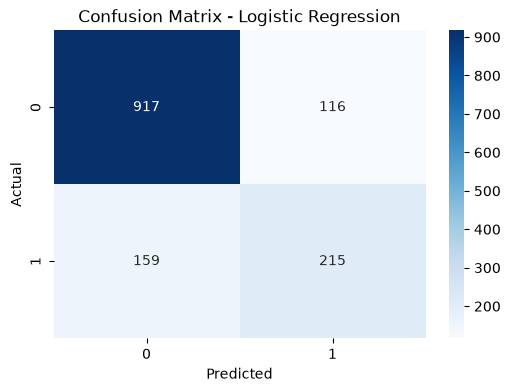

In [ ]:
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
'''
TN = 917
Actual = 0, Predicted = 0
Model correctly said customer will not churn
FP = 116
Actual = 0, Predicted = 1
Model wrongly said customer will churn, but actually they did not
FN = 159
Actual = 1, Predicted = 0
Model wrongly said customer will not churn, but actually they churned
TP = 215
Actual = 1, Predicted = 1
Model correctly said customer will churn'''

In [17]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=42
    ))
])

In [18]:
rf_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='pa

In [19]:
y_pred_rf = rf_pipeline.predict(X_test)
y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]

In [20]:
print("Random Forest Performance")
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_rf))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

Random Forest Performance
Accuracy : 0.7889125799573561
Precision: 0.6237942122186495
Recall   : 0.5187165775401069
F1 Score : 0.5664233576642336
ROC-AUC  : 0.8134191985339414

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.62      0.52      0.57       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



## Why ROC-AUC is used
ROC-AUC is useful in customer churn prediction because it measures how well the model distinguishes churners from non-churners across all classification thresholds. It is especially helpful for imbalanced datasets where accuracy alone may be misleading. A higher ROC-AUC means the model is better at ranking actual churn customers with higher churn probabilities than non-churn customers.

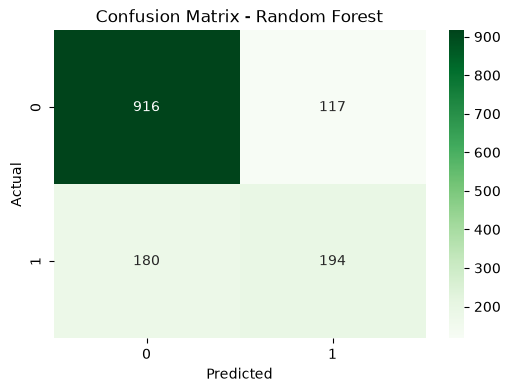

In [21]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [22]:
def evaluate_model(name, y_true, y_pred, y_prob):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_prob)
    }

In [23]:
results = []

results.append(evaluate_model("Logistic Regression", y_test, y_pred_lr, y_prob_lr))
results.append(evaluate_model("Random Forest", y_test, y_pred_rf, y_prob_rf))

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.804549,0.649547,0.574866,0.609929,0.835934
1,Random Forest,0.788913,0.623794,0.518717,0.566423,0.813419


In [24]:
from sklearn.model_selection import RandomizedSearchCV

In [25]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])

In [26]:
param_dist = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [None, 5, 10, 15, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", None]
}

In [27]:
rf_random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_dist,
    n_iter=20,
    scoring="roc_auc",
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

In [28]:
rf_random_search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV] END model__max_depth=10, model__max_features=sqrt, model__min_samples_leaf=2, model__min_samples_split=2, model__n_estimators=200; total time=   0.6s
[CV] END model__max_depth=10, model__max_features=sqrt, model__min_samples_leaf=2, model__min_samples_split=2, model__n_estimators=200; total time=   0.6s
[CV] END model__max_depth=10, model__max_features=sqrt, model__min_samples_leaf=2, model__min_samples_split=2, model__n_estimators=200; total time=   0.6s
[CV] END model__max_depth=10, model__max_features=sqrt, model__min_samples_leaf=2, model__min_samples_split=2, model__n_estimators=200; total time=   0.6s
[CV] END model__max_depth=10, model__max_features=sqrt, model__min_samples_leaf=2, model__min_samples_split=2, model__n_estimators=200; total time=   0.6s
[CV] END model__max_depth=None, model__max_features=None, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=200; total time=   2.4s
[CV] E

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__max_depth': [None, 5, ...], 'model__max_features': ['sqrt', 'log2', ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refi

In [30]:
print("Best Parameters:")
print(rf_random_search.best_params_)

print("\nBest CV ROC-AUC:")
print(rf_random_search.best_score_)

Best Parameters:
{'model__n_estimators': 200, 'model__min_samples_split': 10, 'model__min_samples_leaf': 1, 'model__max_features': 'sqrt', 'model__max_depth': 5}

Best CV ROC-AUC:
0.844923352255703


In [31]:
best_rf = rf_random_search.best_estimator_

In [32]:
y_pred_rf_tuned = best_rf.predict(X_test)
y_prob_rf_tuned = best_rf.predict_proba(X_test)[:, 1]

In [33]:
print("Tuned Random Forest Performance")
print("Accuracy :", accuracy_score(y_test, y_pred_rf_tuned))
print("Precision:", precision_score(y_test, y_pred_rf_tuned))
print("Recall   :", recall_score(y_test, y_pred_rf_tuned))
print("F1 Score :", f1_score(y_test, y_pred_rf_tuned))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_rf_tuned))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf_tuned))

Tuned Random Forest Performance
Accuracy : 0.7853589196872779
Precision: 0.6538461538461539
Recall   : 0.4090909090909091
F1 Score : 0.5032894736842105
ROC-AUC  : 0.833886815308716

Classification Report:

              precision    recall  f1-score   support

           0       0.81      0.92      0.86      1033
           1       0.65      0.41      0.50       374

    accuracy                           0.79      1407
   macro avg       0.73      0.67      0.68      1407
weighted avg       0.77      0.79      0.77      1407



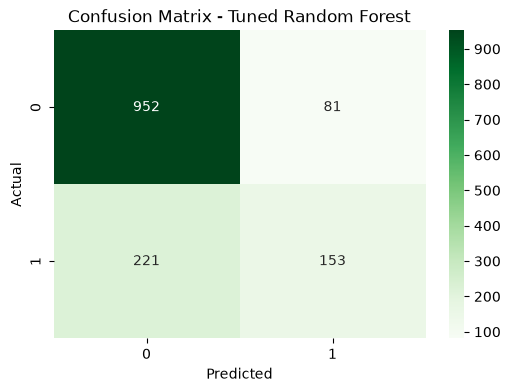

In [34]:
cm_rf_tuned = confusion_matrix(y_test, y_pred_rf_tuned)

plt.figure(figsize=(6,4))
sns.heatmap(cm_rf_tuned, annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix - Tuned Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [36]:
results = []

results.append(evaluate_model("Logistic Regression", y_test, y_pred_lr, y_prob_lr))
results.append(evaluate_model("Random Forest", y_test, y_pred_rf, y_prob_rf))
results.append(evaluate_model("Tuned Random Forest", y_test, y_pred_rf_tuned, y_prob_rf_tuned))

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.804549,0.649547,0.574866,0.609929,0.835934
1,Random Forest,0.788913,0.623794,0.518717,0.566423,0.813419
2,Tuned Random Forest,0.785359,0.653846,0.409091,0.503289,0.833887


In [37]:
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

In [38]:
param_grid_lr = [
    {
        "model__penalty": ["l2"],
        "model__C": [0.01, 0.1, 1, 10],
        "model__class_weight": [None, "balanced"],
        "model__solver": ["lbfgs", "liblinear"]
    },
    {
        "model__penalty": ["l1"],
        "model__C": [0.01, 0.1, 1, 10],
        "model__class_weight": [None, "balanced"],
        "model__solver": ["liblinear"]
    }
]

In [39]:
from sklearn.model_selection import GridSearchCV

grid_lr = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=param_grid_lr,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    verbose=2
)

In [40]:
grid_lr.fit(X_train, y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


/Users/divyanshupandey/Desktop/Custormer_Churn_Predictor/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/divyanshupandey/Desktop/Custormer_Churn_Predictor/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf inst

[CV] END model__C=0.01, model__class_weight=None, model__penalty=l2, model__solver=liblinear; total time=   0.0s
[CV] END model__C=0.01, model__class_weight=None, model__penalty=l2, model__solver=liblinear; total time=   0.1s
[CV] END model__C=0.01, model__class_weight=None, model__penalty=l2, model__solver=lbfgs; total time=   0.0s
[CV] END model__C=0.01, model__class_weight=None, model__penalty=l2, model__solver=lbfgs; total time=   0.1s
[CV] END model__C=0.01, model__class_weight=None, model__penalty=l2, model__solver=liblinear; total time=   0.0s
[CV] END model__C=0.01, model__class_weight=None, model__penalty=l2, model__solver=liblinear; total time=   0.0s
[CV] END model__C=0.01, model__class_weight=None, model__penalty=l2, model__solver=liblinear; total time=   0.1s
[CV] END model__C=0.01, model__class_weight=None, model__penalty=l2, model__solver=lbfgs; total time=   0.1s
[CV] END model__C=0.01, model__class_weight=None, model__penalty=l2, model__solver=lbfgs; total time=   0.1s

/Users/divyanshupandey/Desktop/Custormer_Churn_Predictor/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/divyanshupandey/Desktop/Custormer_Churn_Predictor/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf inst

[CV] END model__C=0.01, model__class_weight=balanced, model__penalty=l2, model__solver=lbfgs; total time=   0.1s
[CV] END model__C=0.01, model__class_weight=balanced, model__penalty=l2, model__solver=lbfgs; total time=   0.0s
[CV] END model__C=0.01, model__class_weight=balanced, model__penalty=l2, model__solver=lbfgs; total time=   0.1s
[CV] END model__C=0.01, model__class_weight=balanced, model__penalty=l2, model__solver=liblinear; total time=   0.0s
[CV] END model__C=0.01, model__class_weight=balanced, model__penalty=l2, model__solver=liblinear; total time=   0.0s
[CV] END model__C=0.01, model__class_weight=balanced, model__penalty=l2, model__solver=liblinear; total time=   0.1s
[CV] END model__C=0.1, model__class_weight=None, model__penalty=l2, model__solver=lbfgs; total time=   0.0s
[CV] END model__C=0.01, model__class_weight=balanced, model__penalty=l2, model__solver=liblinear; total time=   0.1s
[CV] END model__C=0.1, model__class_weight=None, model__penalty=l2, model__solver=lbf

/Users/divyanshupandey/Desktop/Custormer_Churn_Predictor/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/divyanshupandey/Desktop/Custormer_Churn_Predictor/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf inst

[CV] END model__C=1, model__class_weight=None, model__penalty=l2, model__solver=liblinear; total time=   0.1s
[CV] END model__C=1, model__class_weight=None, model__penalty=l2, model__solver=liblinear; total time=   0.0s
[CV] END model__C=1, model__class_weight=None, model__penalty=l2, model__solver=liblinear; total time=   0.0s
[CV] END model__C=1, model__class_weight=None, model__penalty=l2, model__solver=liblinear; total time=   0.1s
[CV] END model__C=1, model__class_weight=balanced, model__penalty=l2, model__solver=lbfgs; total time=   0.0s
[CV] END model__C=1, model__class_weight=None, model__penalty=l2, model__solver=liblinear; total time=   0.1s
[CV] END model__C=1, model__class_weight=balanced, model__penalty=l2, model__solver=lbfgs; total time=   0.1s
[CV] END model__C=1, model__class_weight=balanced, model__penalty=l2, model__solver=lbfgs; total time=   0.0s
[CV] END model__C=1, model__class_weight=balanced, model__penalty=l2, model__solver=lbfgs; total time=   0.1s
[CV] END m

/Users/divyanshupandey/Desktop/Custormer_Churn_Predictor/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/divyanshupandey/Desktop/Custormer_Churn_Predictor/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf inst

[CV] END model__C=10, model__class_weight=balanced, model__penalty=l2, model__solver=liblinear; total time=   0.1s
[CV] END model__C=10, model__class_weight=balanced, model__penalty=l2, model__solver=liblinear; total time=   0.1s
[CV] END model__C=0.01, model__class_weight=None, model__penalty=l1, model__solver=liblinear; total time=   0.0s
[CV] END model__C=10, model__class_weight=balanced, model__penalty=l2, model__solver=liblinear; total time=   0.1s
[CV] END model__C=0.01, model__class_weight=None, model__penalty=l1, model__solver=liblinear; total time=   0.1s
[CV] END model__C=0.01, model__class_weight=balanced, model__penalty=l1, model__solver=liblinear; total time=   0.1s
[CV] END model__C=0.01, model__class_weight=None, model__penalty=l1, model__solver=liblinear; total time=   0.1s
[CV] END model__C=0.01, model__class_weight=balanced, model__penalty=l1, model__solver=liblinear; total time=   0.1s
[CV] END model__C=0.1, model__class_weight=None, model__penalty=l1, model__solver=

/Users/divyanshupandey/Desktop/Custormer_Churn_Predictor/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/divyanshupandey/Desktop/Custormer_Churn_Predictor/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/divyanshupandey/Desktop/Custormer_Churn_Predictor/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To 

[CV] END model__C=1, model__class_weight=balanced, model__penalty=l1, model__solver=liblinear; total time=   0.1s
[CV] END model__C=1, model__class_weight=balanced, model__penalty=l1, model__solver=liblinear; total time=   0.1s
[CV] END model__C=1, model__class_weight=balanced, model__penalty=l1, model__solver=liblinear; total time=   0.1s
[CV] END model__C=1, model__class_weight=balanced, model__penalty=l1, model__solver=liblinear; total time=   0.1s
[CV] END model__C=1, model__class_weight=None, model__penalty=l1, model__solver=liblinear; total time=   0.2s
[CV] END model__C=10, model__class_weight=None, model__penalty=l1, model__solver=liblinear; total time=   0.3s
[CV] END model__C=1, model__class_weight=balanced, model__penalty=l1, model__solver=liblinear; total time=   0.3s
[CV] END model__C=10, model__class_weight=None, model__penalty=l1, model__solver=liblinear; total time=   0.4s
[CV] END model__C=10, model__class_weight=None, model__penalty=l1, model__solver=liblinear; total 

/Users/divyanshupandey/Desktop/Custormer_Churn_Predictor/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/divyanshupandey/Desktop/Custormer_Churn_Predictor/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


[CV] END model__C=10, model__class_weight=balanced, model__penalty=l1, model__solver=liblinear; total time=   0.4s
[CV] END model__C=10, model__class_weight=balanced, model__penalty=l1, model__solver=liblinear; total time=   0.4s
[CV] END model__C=10, model__class_weight=balanced, model__penalty=l1, model__solver=liblinear; total time=   0.4s
[CV] END model__C=10, model__class_weight=balanced, model__penalty=l1, model__solver=liblinear; total time=   0.3s


/Users/divyanshupandey/Desktop/Custormer_Churn_Predictor/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'model__C': [0.01, 0.1, ...], 'model__class_weight': [None, 'balanced'], 'model__penalty': ['l2'], 'model__solver': ['lbfgs', 'liblinear']}, {'model__C': [0.01, 0.1, ...], 'model__class_weight': [None, 'balanced'], 'model__penalty': ['l1'], 'model__solver': ['liblinear']}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and a

In [41]:
print("Best Parameters:", grid_lr.best_params_)
print("Best CV ROC-AUC:", grid_lr.best_score_)

Best Parameters: {'model__C': 10, 'model__class_weight': None, 'model__penalty': 'l2', 'model__solver': 'liblinear'}
Best CV ROC-AUC: 0.8461882627321093


In [42]:
best_lr = grid_lr.best_estimator_

In [43]:
y_pred_lr_tuned = best_lr.predict(X_test)
y_prob_lr_tuned = best_lr.predict_proba(X_test)[:, 1]

In [44]:
print("Tuned Logistic Regression Performance")
print("Accuracy :", accuracy_score(y_test, y_pred_lr_tuned))
print("Precision:", precision_score(y_test, y_pred_lr_tuned))
print("Recall   :", recall_score(y_test, y_pred_lr_tuned))
print("F1 Score :", f1_score(y_test, y_pred_lr_tuned))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_lr_tuned))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr_tuned))

Tuned Logistic Regression Performance
Accuracy : 0.8002842928216063
Precision: 0.6388059701492538
Recall   : 0.5721925133689839
F1 Score : 0.6036671368124118
ROC-AUC  : 0.8352508916969938

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.88      0.87      1033
           1       0.64      0.57      0.60       374

    accuracy                           0.80      1407
   macro avg       0.74      0.73      0.74      1407
weighted avg       0.79      0.80      0.80      1407



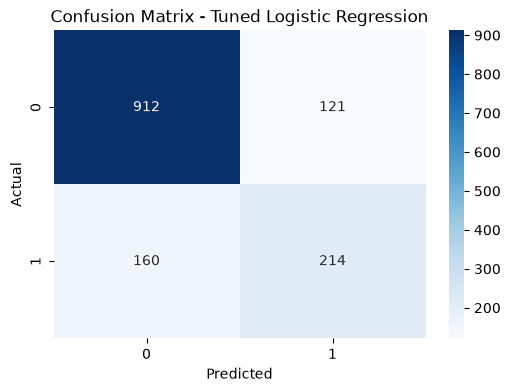

In [45]:
cm_lr_tuned = confusion_matrix(y_test, y_pred_lr_tuned)

plt.figure(figsize=(6,4))
sns.heatmap(cm_lr_tuned, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Tuned Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [46]:
results = []

results.append(evaluate_model("Logistic Regression", y_test, y_pred_lr, y_prob_lr))
results.append(evaluate_model("Random Forest", y_test, y_pred_rf, y_prob_rf))
results.append(evaluate_model("Tuned Random Forest", y_test, y_pred_rf_tuned, y_prob_rf_tuned))
results.append(evaluate_model("Tuned Logistic Regression", y_test, y_pred_lr_tuned, y_prob_lr_tuned))

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.804549,0.649547,0.574866,0.609929,0.835934
1,Random Forest,0.788913,0.623794,0.518717,0.566423,0.813419
2,Tuned Random Forest,0.785359,0.653846,0.409091,0.503289,0.833887
3,Tuned Logistic Regression,0.800284,0.638806,0.572193,0.603667,0.835251


In [47]:
from xgboost import XGBClassifier

In [48]:
# XGBoost Pipeline
xgb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42
    ))
])

In [49]:
xgb_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='pa

In [50]:
y_pred_xgb = xgb_pipeline.predict(X_test)
y_prob_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]

In [51]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report
)

xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_precision = precision_score(y_test, y_pred_xgb)
xgb_recall = recall_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb)
xgb_roc_auc = roc_auc_score(y_test, y_prob_xgb)

print("XGBoost Results")
print("Accuracy :", xgb_accuracy)
print("Precision:", xgb_precision)
print("Recall   :", xgb_recall)
print("F1 Score :", xgb_f1)
print("ROC-AUC  :", xgb_roc_auc)

XGBoost Results
Accuracy : 0.7960199004975125
Precision: 0.6407766990291263
Recall   : 0.5294117647058824
F1 Score : 0.5797950219619327
ROC-AUC  : 0.8368285094553529


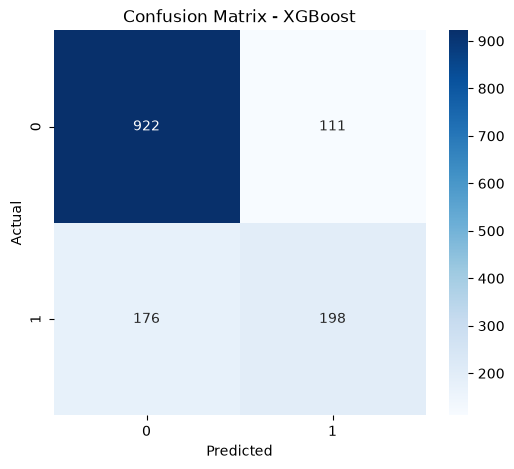

In [52]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6,5))
sns.heatmap(cm_xgb, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [53]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1033
           1       0.64      0.53      0.58       374

    accuracy                           0.80      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.79      0.80      0.79      1407



In [54]:
xgb_results = pd.DataFrame([{
    "Model": "XGBoost",
    "Accuracy": xgb_accuracy,
    "Precision": xgb_precision,
    "Recall": xgb_recall,
    "F1 Score": xgb_f1,
    "ROC-AUC": xgb_roc_auc
}])

results_df = pd.concat([results_df, xgb_results], ignore_index=True)
results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.804549,0.649547,0.574866,0.609929,0.835934
1,Random Forest,0.788913,0.623794,0.518717,0.566423,0.813419
2,Tuned Random Forest,0.785359,0.653846,0.409091,0.503289,0.833887
3,Tuned Logistic Regression,0.800284,0.638806,0.572193,0.603667,0.835251
4,XGBoost,0.796020,0.640777,0.529412,0.579795,0.836829


In [55]:
xgb_tune_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42
    ))
])

In [56]:
param_grid_xgb = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [3, 4, 5],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0]
}

In [64]:
grid_xgb = GridSearchCV(
    estimator=xgb_tune_pipeline,
    param_grid=param_grid_xgb,
    cv=7,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=2
)

grid_xgb.fit(X_train, y_train)

Fitting 7 folds for each of 108 candidates, totalling 756 fits
[CV] END model__colsample_bytree=0.8, model__learning_rate=0.03, model__max_depth=3, model__n_estimators=100, model__subsample=0.8; total time=   0.2s
[CV] END model__colsample_bytree=0.8, model__learning_rate=0.03, model__max_depth=3, model__n_estimators=100, model__subsample=0.8; total time=   0.2s
[CV] END model__colsample_bytree=0.8, model__learning_rate=0.03, model__max_depth=3, model__n_estimators=100, model__subsample=0.8; total time=   0.2s
[CV] END model__colsample_bytree=0.8, model__learning_rate=0.03, model__max_depth=3, model__n_estimators=100, model__subsample=0.8; total time=   0.2s
[CV] END model__colsample_bytree=0.8, model__learning_rate=0.03, model__max_depth=3, model__n_estimators=100, model__subsample=0.8; total time=   0.2s
[CV] END model__colsample_bytree=0.8, model__learning_rate=0.03, model__max_depth=3, model__n_estimators=100, model__subsample=0.8; total time=   0.2s
[CV] END model__colsample_bytre

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__colsample_bytree': [0.8, 1.0], 'model__learning_rate': [0.03, 0.05, ...], 'model__max_depth': [3, 4, ...], 'model__n_estimators': [100, 200, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",7
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple met

In [65]:
print("Best XGBoost Parameters:", grid_xgb.best_params_)
print("Best CV ROC-AUC:", grid_xgb.best_score_)

Best XGBoost Parameters: {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.03, 'model__max_depth': 3, 'model__n_estimators': 200, 'model__subsample': 0.8}
Best CV ROC-AUC: 0.8507437199361755


In [66]:
best_xgb = grid_xgb.best_estimator_

In [67]:
y_pred_xgb_tuned = best_xgb.predict(X_test)
y_prob_xgb_tuned = best_xgb.predict_proba(X_test)[:, 1]

In [68]:
xgb_tuned_accuracy = accuracy_score(y_test, y_pred_xgb_tuned)
xgb_tuned_precision = precision_score(y_test, y_pred_xgb_tuned)
xgb_tuned_recall = recall_score(y_test, y_pred_xgb_tuned)
xgb_tuned_f1 = f1_score(y_test, y_pred_xgb_tuned)
xgb_tuned_roc_auc = roc_auc_score(y_test, y_prob_xgb_tuned)

print("Tuned XGBoost Results")
print("Accuracy :", xgb_tuned_accuracy)
print("Precision:", xgb_tuned_precision)
print("Recall   :", xgb_tuned_recall)
print("F1 Score :", xgb_tuned_f1)
print("ROC-AUC  :", xgb_tuned_roc_auc)

Tuned XGBoost Results
Accuracy : 0.7938877043354655
Precision: 0.6390728476821192
Recall   : 0.516042780748663
F1 Score : 0.5710059171597633
ROC-AUC  : 0.8408741477758048


In [69]:
print(classification_report(y_test, y_pred_xgb_tuned))

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.64      0.52      0.57       374

    accuracy                           0.79      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.78      0.79      0.79      1407



In [71]:
xgb_tuned_results = pd.DataFrame([{
    "Model": "Tuned XGBoost with cv 7",
    "Accuracy": xgb_tuned_accuracy,
    "Precision": xgb_tuned_precision,
    "Recall": xgb_tuned_recall,
    "F1 Score": xgb_tuned_f1,
    "ROC-AUC": xgb_tuned_roc_auc
}])

results_df = pd.concat([results_df, xgb_tuned_results], ignore_index=True)
results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.804549,0.649547,0.574866,0.609929,0.835934
1,Random Forest,0.788913,0.623794,0.518717,0.566423,0.813419
2,Tuned Random Forest,0.785359,0.653846,0.409091,0.503289,0.833887
3,Tuned Logistic Regression,0.800284,0.638806,0.572193,0.603667,0.835251
4,XGBoost,0.796020,0.640777,0.529412,0.579795,0.836829
5,Tuned XGBoost,0.793888,0.639073,0.516043,0.571006,0.840874
6,Tuned XGBoost,0.793888,0.639073,0.516043,0.571006,0.840874
7,Tuned XGBoost with cv 7,0.793888,0.639073,0.516043,0.571006,0.840874


In [ ]:
results_df.drop(index=6, inplace=True)

In [82]:
results_df = results_df.drop(index=7).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.804549,0.649547,0.574866,0.609929,0.835934
1,Random Forest,0.788913,0.623794,0.518717,0.566423,0.813419
2,Tuned Random Forest,0.785359,0.653846,0.409091,0.503289,0.833887
3,Tuned Logistic Regression,0.800284,0.638806,0.572193,0.603667,0.835251
4,XGBoost,0.796020,0.640777,0.529412,0.579795,0.836829
5,Tuned XGBoost,0.793888,0.639073,0.516043,0.571006,0.840874


# thing to focus on 
“Why do you think Logistic Regression outperformed XGBoost here?”

You can answer like this:

In this churn dataset, many of the strongest predictors such as tenure, contract type, monthly charges, tech support, and online security had fairly direct and monotonic relationships with churn. After one-hot encoding the categorical features, the problem became well-suited to a linear model. Logistic Regression was able to capture these additive relationships effectively and generalized well on the test set.

XGBoost is more expressive and achieved slightly better ROC-AUC, which suggests it ranked churn risk well, but at the default classification threshold it did not convert that into better recall and F1. So in this case, the simpler model gave a better overall classification tradeoff and was also easier to interpret.

### Since false negatives correspond to actual churners that the model fails to identify, reducing FN is important for churn management. Therefore, recall becomes a key metric, because higher recall means the model is catching a larger fraction of real churners. However, recall should be considered along with precision and F1-score, so that the model does not flag too many non-churn customers unnecessarily.

In [83]:
import os
import joblib

os.makedirs("../artifacts", exist_ok=True)
joblib.dump(log_reg_pipeline, "../artifacts/final_model.pkl")
print("Final model saved successfully.")

Final model saved successfully.


In [84]:
results_df.to_csv("../artifacts/model_results.csv", index=False)

# Final Model Selection

After comparing Logistic Regression, Random Forest, and XGBoost-based models, **Logistic Regression** was selected as the final model.

## Reason for selection
- Highest **Recall**
- Highest **F1-score**
- Strong **Accuracy**
- Competitive **ROC-AUC**
- More interpretable and lightweight than tree-based boosting models

## Final Choice
**Selected Model: Logistic Regression**

## Model Training Understanding

![Model Training Understanding](../artifacts/visuals/model_training.png)